# Project 2 — LendingClub Credit Funnel
## Notebook 01: Exploratory Data Analysis, Data-Quality Audit & Leakage Review

**Author:** Eric Bowers · **Framework:** CRISP-DM (Data Understanding stage)

**BLUF.** This notebook profiles the two LendingClub files, builds the binary
default target on *terminal* loans only, audits every accepted-file column for
**data leakage** (post-origination fields that would make the model an
unrealistic near-perfect predictor), and produces the EDA visuals that motivate
the preprocessing and modeling choices in the next notebook.

**What this notebook produces (for downstream use):**
1. A documented **feature whitelist** (application-time columns that are safe to model on).
2. A documented **leakage blacklist** + **near-empty column list** to drop.
3. A cleaned, target-labelled **terminal-loan sample** saved to `data/interim/` for fast iteration.
4. A harmonized **accepted-vs-rejected** comparison for the access/policy analysis.

> **Runtime note.** The raw files are ~6.3 GB (accepted) and ~10.5 GB (rejected)
> in memory. This notebook is written to be *memory-aware*: it loads only the
> columns it needs, downcasts dtypes, and **samples** the 27.6M-row rejected file.
> On a machine with < 16 GB RAM, keep `SAMPLE_ACCEPTED = True` in the config cell.

## 0 · Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.3 | numpy 1.26.4


### 0.1 · Configuration

Edit `DATA_DIR` to point at the folder holding the two Kaggle CSVs. Everything
else is derived from it. Set `SAMPLE_ACCEPTED = True` to work on a random subset
while developing (faster, lower memory); flip it to `False` for the full run.

In [4]:


ACCEPTED_CSV = "accepted_2007_to_2018Q4.csv"
REJECTED_CSV = "rejected_2007_to_2018Q4.csv"

INTERIM_DIR = "/data/interim"
os.makedirs(INTERIM_DIR, exist_ok=True)

# Development switches
SAMPLE_ACCEPTED   = False      # True -> load a random fraction of accepted rows
ACCEPTED_FRAC     = 0.20       # fraction used when SAMPLE_ACCEPTED is True
REJECTED_SAMPLE_N = 500_000    # rows to keep from the 27.6M-row rejected file

for p in (ACCEPTED_CSV, REJECTED_CSV):
    print(("OK   " if os.path.exists(p) else "MISSING ->"), p)

MISSING -> accepted_2007_to_2018Q4.csv
MISSING -> rejected_2007_to_2018Q4.csv


### 0.2 · Helpers

`reduce_mem_usage` downcasts numeric dtypes; `missingness` returns a sorted
null-rate table. Both are used repeatedly below.

In [3]:
def reduce_mem_usage(df, verbose=True):
    """Downcast numeric columns to the smallest safe dtype."""
    start = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        t = df[col].dtype
        if pd.api.types.is_integer_dtype(t):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        elif pd.api.types.is_float_dtype(t):
            df[col] = pd.to_numeric(df[col], downcast="float")
    end = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory: {start:,.1f} MB -> {end:,.1f} MB  ({100*(start-end)/start:,.1f}% smaller)")
    return df


def missingness(df, top=None):
    """Null count / percent per column, most-missing first."""
    n = len(df)
    m = pd.DataFrame({
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(2),
        "dtype": df.dtypes.astype(str),
        "n_unique": df.nunique(dropna=True),
    }).sort_values("pct_missing", ascending=False)
    return m.head(top) if top else m


def pct_str_to_float(s):
    """'38.64%' or ' 13.99 ' -> 38.64 / 13.99 (float)."""
    return (s.astype(str)
             .str.replace("%", "", regex=False)
             .str.strip()
             .replace({"nan": np.nan, "": np.nan})
             .astype(float))

## 1 · Accepted loans — load & first look

The accepted file has 151 columns. We load it fully (or a sample) for profiling,
downcast immediately, and inspect shape, dtypes, and memory. If your machine is
tight on RAM, set `SAMPLE_ACCEPTED = True` above — the leakage audit and target
logic are identical on a sample.

In [4]:
read_kwargs = dict(low_memory=False)
if SAMPLE_ACCEPTED:
    # Deterministic row sampling without loading the whole file into memory first:
    # keep a row with probability ACCEPTED_FRAC using a hashed skiprows callable.
    import random
    rng = random.Random(RANDOM_STATE)
    read_kwargs["skiprows"] = lambda i: i > 0 and rng.random() > ACCEPTED_FRAC

acc = pd.read_csv(ACCEPTED_CSV, **read_kwargs)
print("Raw shape:", acc.shape)
acc = reduce_mem_usage(acc)

Raw shape: (2260701, 151)
Memory: 6,414.7 MB -> 5,552.3 MB  (13.4% smaller)


In [5]:
acc.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.029999,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.910000,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.700001,13.0,w,0.0,0.0,4421.723917,4421.72,3600.0,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.200001,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.900002,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.280029,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.059999,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.200001,38.0,w,0.0,0.0,25679.660000,25679.66,24700.0,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.100000,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.400002,7.7,0.0,0.0,314017.0,39475

In [6]:
print("Rows:", f"{len(acc):,}", "| Columns:", acc.shape[1])
print("\nDtype counts:")
print(acc.dtypes.value_counts())
print("\nApprox in-memory size: "
      f"{acc.memory_usage(deep=True).sum()/1024**3:,.2f} GB")

Rows: 2,260,701 | Columns: 151

Dtype counts:
float32    100
object      38
float64     13
Name: count, dtype: int64

Approx in-memory size: 5.42 GB


### 1.1 · The "33 junk rows"

The pitch flagged that a small number of rows are entirely blank on the core
fields (an artifact of the CSV export). Rather than hard-code `33`, we detect
rows where a set of always-populated core fields are *all* null and drop them.

In [7]:
core_fields = [c for c in ["loan_amnt", "term", "loan_status", "issue_d", "grade"]
               if c in acc.columns]
junk_mask = acc[core_fields].isna().all(axis=1)
print(f"Junk rows (all core fields null): {junk_mask.sum():,}")

acc = acc.loc[~junk_mask].reset_index(drop=True)
print("Shape after dropping junk rows:", acc.shape)

Junk rows (all core fields null): 33
Shape after dropping junk rows: (2260668, 151)


### 1.2 · Missingness landscape

Sorting by null-rate surfaces the near-empty blocks the pitch identified:
`member_id` (100%), the `hardship_*` / `settlement_*` / `sec_app_*` (joint) blocks
(~95–99%), and `desc` (~94%). These are dropped in preprocessing — shown here so
the decision is evidence-based.

In [8]:
miss = missingness(acc)
miss.head(30)

,n_missing,pct_missing,dtype,n_unique
member_id,2260668,100.00,float32,0
orig_projected_additional_accrued_interest,2252017,99.62,float32,7487
hardship_end_date,2249751,99.52,object,28
hardship_start_date,2249751,99.52,object,27
hardship_type,2249751,99.52,object,1
hardship_reason,2249751,99.52,object,9
hardship_status,2249751,99.52,object,3
deferral_term,2249751,99.52,float32,1
hardship_last_payment_amount,2249751,99.52,float32,9045
hardship_payoff_balance_amount,2249751,99.52,float64,10893


In [9]:
# Buckets of columns by missingness, for the preprocessing plan.
def cols_between(lo, hi):
    r = miss[(miss.pct_missing >= lo) & (miss.pct_missing < hi)]
    return list(r.index)

near_empty = cols_between(90, 100.01)      # drop candidates
heavy_miss = cols_between(38, 90)          # flag-or-drop after testing
some_miss  = cols_between(0.001, 38)       # impute

print(f"Near-empty (>=90% null), drop candidates: {len(near_empty)}")
print(near_empty)
print(f"\nHeavy (38-90% null), flag-or-drop: {len(heavy_miss)}")
print(heavy_miss[:40])
print(f"\nModerate (<38% null), impute: {len(some_miss)}")

Near-empty (>=90% null), drop candidates: 38
['member_id', 'orig_projected_additional_accrued_interest', 'hardship_end_date', 'hardship_start_date', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_last_payment_amount', 'hardship_payoff_balance_amount', 'hardship_loan_status', 'hardship_dpd', 'hardship_length', 'payment_plan_start_date', 'hardship_amount', 'settlement_term', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'sec_app_mort_acc', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_open_acc', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'verification_status_joint', 'dti_joint', 'annual_inc_joint', 'desc']

Heavy (38-90% null), flag-or-drop: 20
['mths_since_las

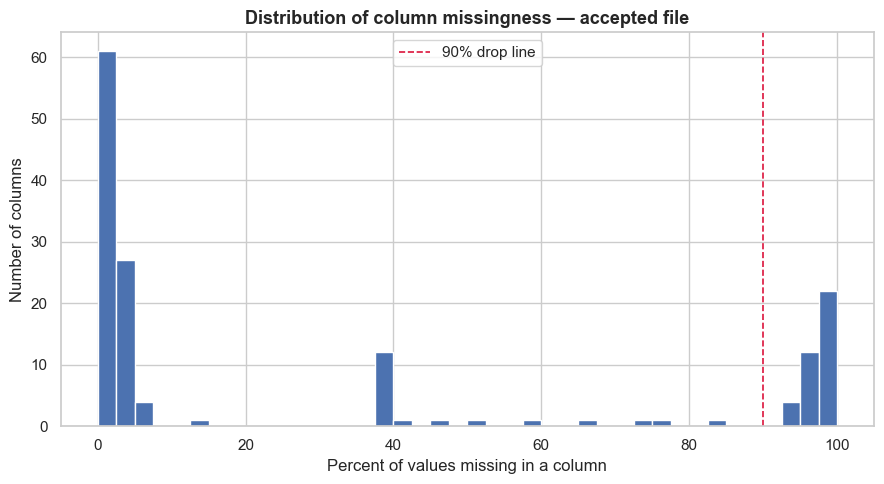

In [10]:
# Visualize the missingness distribution across all columns.
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(miss.pct_missing, bins=40, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of column missingness — accepted file")
ax.set_xlabel("Percent of values missing in a column")
ax.set_ylabel("Number of columns")
ax.axvline(90, color="crimson", ls="--", lw=1.2, label="90% drop line")
ax.legend()
plt.tight_layout(); plt.show()

## 2 · Target construction — terminal loans only

`loan_status` has 9 categories. We keep only **terminal** loans (final outcome
known) and map them to a binary target:

| Target | `loan_status` values |
|---|---|
| **1 — default** | `Charged Off`, `Default`, `Does not meet the credit policy. Status:Charged Off` |
| **0 — repaid** | `Fully Paid`, `Does not meet the credit policy. Status:Fully Paid` |
| **excluded** | `Current`, `In Grace Period`, `Late (16-30 days)`, `Late (31-120 days)` |

The excluded rows have no final outcome yet and would inject label noise.

In [11]:
print(acc["loan_status"].value_counts(dropna=False))

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [12]:
default_states = {
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
}
repaid_states = {
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
}
terminal_states = default_states | repaid_states

acc["is_terminal"] = acc["loan_status"].isin(terminal_states)
print(f"Terminal loans: {acc['is_terminal'].sum():,} "
      f"({acc['is_terminal'].mean()*100:.1f}% of rows)")

term = acc.loc[acc["is_terminal"]].copy()
term["target"] = term["loan_status"].isin(default_states).astype("int8")

rate = term["target"].mean()
print(f"Modeling set: {len(term):,} loans | default rate = {rate*100:.2f}%")

Terminal loans: 1,348,099 (59.6% of rows)
Modeling set: 1,348,099 loans | default rate = 19.98%


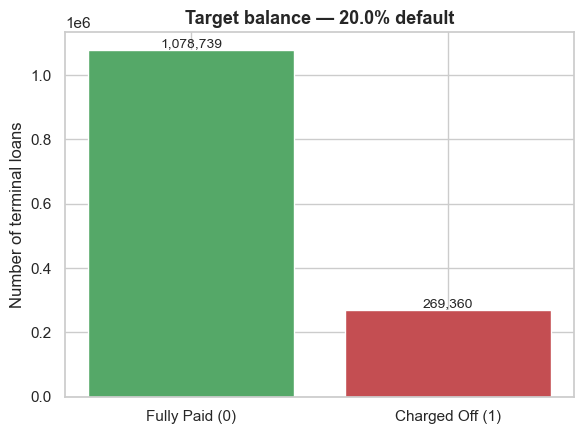

In [13]:
# Target balance visual.
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = term["target"].value_counts().sort_index()
bars = ax.bar(["Fully Paid (0)", "Charged Off (1)"], counts.values,
              color=["#55A868", "#C44E52"])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}",
            ha="center", va="bottom", fontsize=10)
ax.set_title(f"Target balance — {rate*100:.1f}% default")
ax.set_ylabel("Number of terminal loans")
plt.tight_layout(); plt.show()

### 2.1 · Vintage survivorship check (correctness caveat)

Restricting to terminal loans quietly biases the sample: long-term (60-month)
loans issued late in the window are disproportionately still `Current` and get
excluded, so recent vintages are under-represented and skew toward loans that had
time to resolve. This matters because the planned **time-based split** tests on
exactly those late vintages. The plot below makes the censoring visible — expect
the terminal share to fall for recent issue years, especially for 60-month terms.

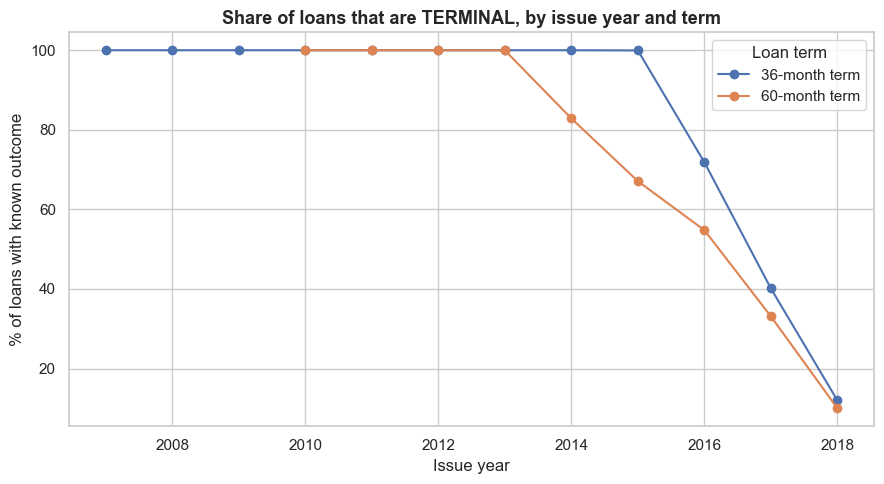

Takeaway: recent 60-month vintages are heavily censored -> note this when interpreting the time-based test split.


In [14]:
tmp = acc.copy()
tmp["issue_dt"] = pd.to_datetime(tmp["issue_d"], format="%b-%Y", errors="coerce")
tmp["issue_year"] = tmp["issue_dt"].dt.year
tmp["term_clean"] = (tmp["term"].astype(str)
                     .str.extract(r"(\d+)").astype(float))

surv = (tmp.dropna(subset=["issue_year", "term_clean"])
          .groupby(["issue_year", "term_clean"])["is_terminal"]
          .mean().mul(100).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
for t, g in surv.groupby("term_clean"):
    ax.plot(g["issue_year"], g["is_terminal"], marker="o",
            label=f"{int(t)}-month term")
ax.set_title("Share of loans that are TERMINAL, by issue year and term")
ax.set_xlabel("Issue year"); ax.set_ylabel("% of loans with known outcome")
ax.legend(title="Loan term"); plt.tight_layout(); plt.show()

print("Takeaway: recent 60-month vintages are heavily censored -> note this "
      "when interpreting the time-based test split.")

## 3 · Leakage audit — the central risk

Many accepted-file columns describe what happened *after* the money went out.
Training on them yields an "unrealistically perfect" model with no business value,
because at **application time** the lender doesn't have them. We categorize every
column into: **application-time (safe)**, **post-origination (leak → drop)**,
**judgment-call (grade/int_rate — test both ways)**, and **identifiers**.

The lists below encode the pitch's whitelist policy; the code then reports which
of them are actually present and what remains as the safe modeling set.

In [15]:
# --- Known post-origination / outcome fields (LEAK -> drop) ------------------
leak_repayment = [
    "funded_amnt", "funded_amnt_inv", "out_prncp", "out_prncp_inv",
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
    "last_fico_range_high", "last_fico_range_low",
]
leak_status_posthoc = [
    "debt_settlement_flag", "pymnt_plan",
    "chargeoff_within_12_mths", "collections_12_mths_ex_med",
]
# Whole prefixed blocks that are post-hoc:
leak_prefixes = ["settlement_", "hardship_"]

# --- Judgment-call: available at origination but partly encode the answer -----
judgment_call = ["grade", "sub_grade", "int_rate"]

# --- Identifiers / free-form / non-features -----------------------------------
identifiers = ["id", "member_id", "url", "desc", "emp_title", "title", "zip_code"]

def matches_prefix(col):
    return any(col.startswith(p) for p in leak_prefixes)

leak_prefix_cols = [c for c in acc.columns if matches_prefix(c)]

leakage_cols = sorted(set(
    [c for c in leak_repayment + leak_status_posthoc if c in acc.columns]
    + leak_prefix_cols
))
print(f"Post-origination LEAK columns present: {len(leakage_cols)}")
print(leakage_cols)

Post-origination LEAK columns present: 38
['chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'funded_amnt', 'funded_amnt_inv', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_flag', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d', 'out_prncp', 'out_prncp_inv', 'pymnt_plan', 'recoveries', 'settlement_amount', 'settlement_date', 'settlement_percentage', 'settlement_status', 'settlement_term', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp']


In [16]:
# Build the audit table: every column tagged with its disposition.
def disposition(col):
    if col == "loan_status":            return "target-source"
    if col in ("target", "is_terminal"):return "derived"
    if col in leakage_cols:             return "LEAK-drop"
    if col in judgment_call:            return "judgment-call (test both)"
    if col in identifiers:              return "identifier/text-drop"
    if col in near_empty:               return "near-empty-drop"
    return "application-time (KEEP)"

audit = pd.DataFrame({"column": acc.columns})
audit["disposition"] = audit["column"].map(disposition)
audit["pct_missing"] = audit["column"].map(miss["pct_missing"])
print(audit["disposition"].value_counts())
audit.sort_values(["disposition", "pct_missing"]).reset_index(drop=True)

disposition
application-time (KEEP)      82
LEAK-drop                    38
near-empty-drop              20
identifier/text-drop          7
judgment-call (test both)     3
target-source                 1
derived                       1
Name: count, dtype: int64


,column,disposition,pct_missing
0,funded_amnt,LEAK-drop,0.00
1,funded_amnt_inv,LEAK-drop,0.00
2,pymnt_plan,LEAK-drop,0.00
3,out_prncp,LEAK-drop,0.00
4,out_prncp_inv,LEAK-drop,0.00
...,...,...,...
147,debt_settlement_flag_date,near-empty-drop,98.49
148,deferral_term,near-empty-drop,99.52
149,payment_plan_start_date,near-empty-drop,99.52
150,orig_projected_additional_accrued_interest,near-empty-drop,99.62


In [17]:
# The safe modeling feature set (application-time + judgment-call, minus near-empty).
whitelist = audit.loc[
    audit["disposition"].isin(["application-time (KEEP)", "judgment-call (test both)"]),
    "column"
].tolist()
print(f"Whitelist size (features available for modeling): {len(whitelist)}")
print(sorted(whitelist))

# Persist the audit for the preprocessing notebook.
audit.to_csv(os.path.join(INTERIM_DIR, "column_audit.csv"), index=False)
print("\nSaved column_audit.csv")

Whitelist size (features available for modeling): 85
['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'all_util', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'il_util', 'initial_list_status', 'inq_fi', 'inq_last_12m', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'loan_amnt', 'max_bal_bc', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_12

> **Leakage sanity check (do this in modeling):** train a quick model *with*
> the leak columns included. If ROC-AUC jumps toward ~0.99, that confirms the
> leak — the whitelist above is what prevents it. We keep that as a deliberate
> "before/after" demonstration rather than a mistake.

## 4 · Univariate distributions & data-quality parsing

Several numeric fields arrive as strings. We parse them here (non-destructively,
into new `*_num` columns) and inspect distributions. `annual_inc` is extremely
right-skewed, motivating a log transform downstream.

In [18]:
# Parse the string-formatted numerics the pitch flagged.
term["term_months"] = term["term"].astype(str).str.extract(r"(\d+)").astype("float")

for col in ["int_rate", "revol_util"]:
    if col in term.columns and term[col].dtype == object:
        term[col + "_num"] = pct_str_to_float(term[col])
    elif col in term.columns:
        term[col + "_num"] = term[col].astype(float)

# FICO midpoint (application-time credit score).
if {"fico_range_low", "fico_range_high"}.issubset(term.columns):
    term["fico_mid"] = (term["fico_range_low"] + term["fico_range_high"]) / 2

term[["term_months", "int_rate_num", "revol_util_num", "fico_mid"]].describe()

,term_months,int_rate_num,revol_util_num,fico_mid
count,1.348099e+06,1.348099e+06,1.347202e+06,1.348099e+06
mean,4.178402e+01,1.324156e+01,5.181200e+01,6.981624e+02
std,1.026458e+01,4.765685e+00,2.452979e+01,3.180564e+01
min,3.600000e+01,5.310000e+00,0.000000e+00,6.120000e+02
25%,3.600000e+01,9.750000e+00,3.340000e+01,6.720000e+02
50%,3.600000e+01,1.274000e+01,5.220000e+01,6.920000e+02
75%,3.600000e+01,1.599000e+01,7.070000e+01,7.120000e+02
max,6.000000e+01,3.099000e+01,8.923000e+02,8.475000e+02


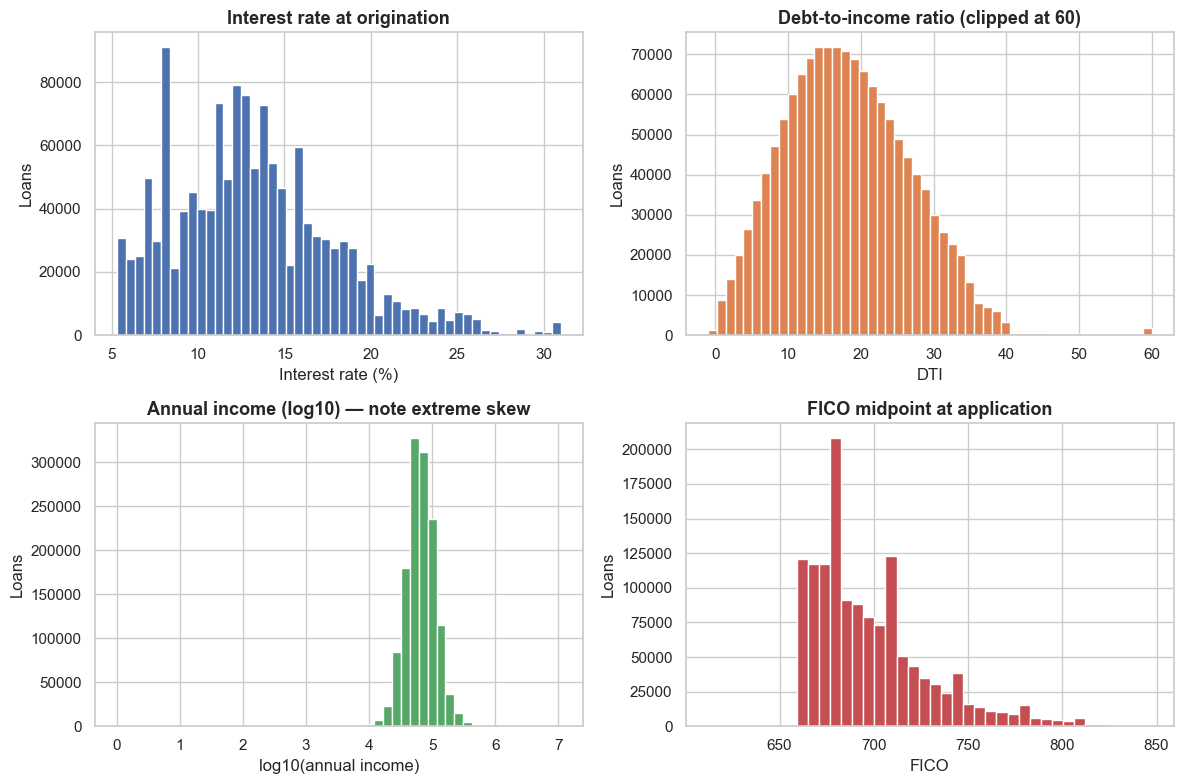

In [19]:
# Distributions of four key numerics (log scale for income).
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(term["int_rate_num"].dropna(), bins=50, color="#4C72B0")
axes[0,0].set_title("Interest rate at origination")
axes[0,0].set_xlabel("Interest rate (%)"); axes[0,0].set_ylabel("Loans")

axes[0,1].hist(term["dti"].dropna().clip(upper=60), bins=50, color="#DD8452")
axes[0,1].set_title("Debt-to-income ratio (clipped at 60)")
axes[0,1].set_xlabel("DTI"); axes[0,1].set_ylabel("Loans")

inc = term["annual_inc"].dropna()
inc = inc[inc > 0]
axes[1,0].hist(np.log10(inc), bins=50, color="#55A868")
axes[1,0].set_title("Annual income (log10) — note extreme skew")
axes[1,0].set_xlabel("log10(annual income)"); axes[1,0].set_ylabel("Loans")

axes[1,1].hist(term["fico_mid"].dropna(), bins=40, color="#C44E52")
axes[1,1].set_title("FICO midpoint at application")
axes[1,1].set_xlabel("FICO"); axes[1,1].set_ylabel("Loans")

plt.tight_layout(); plt.show()

## 5 · What drives default? — charge-off rate by category

For each categorical driver we plot the **default rate** (mean of `target`) per
level, with the portfolio average as a reference line. These are the relationships
the model should recover — and a first fairness/EDA read on the funnel.

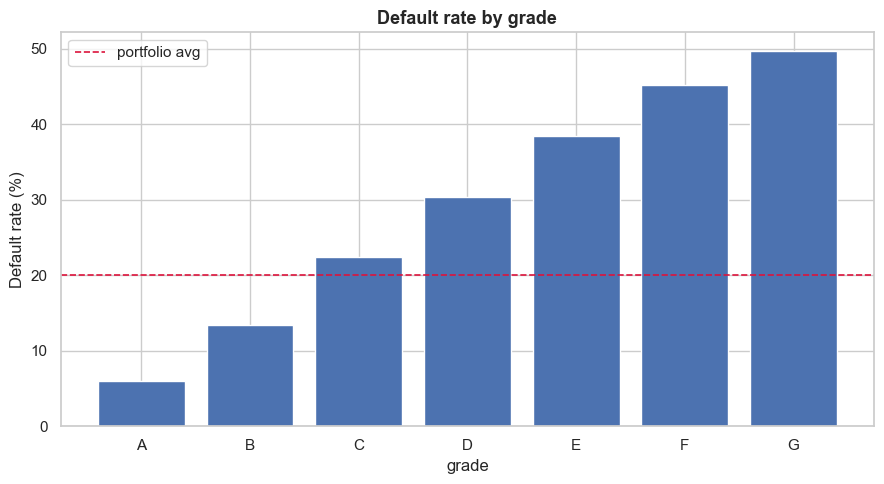

In [20]:
def default_rate_by(cat, order=None, min_n=500, rotate=0, figsize=(9,5)):
    g = term.groupby(cat)["target"].agg(["mean", "size"])
    g = g[g["size"] >= min_n]
    if order is not None:
        g = g.reindex([o for o in order if o in g.index])
    else:
        g = g.sort_values("mean")
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(g.index.astype(str), g["mean"]*100, color="#4C72B0")
    ax.axhline(term["target"].mean()*100, color="crimson", ls="--",
               lw=1.2, label="portfolio avg")
    ax.set_title(f"Default rate by {cat}")
    ax.set_ylabel("Default rate (%)"); ax.set_xlabel(cat)
    if rotate: plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")
    ax.legend(); plt.tight_layout(); plt.show()
    return g

_ = default_rate_by("grade", order=list("ABCDEFG"))

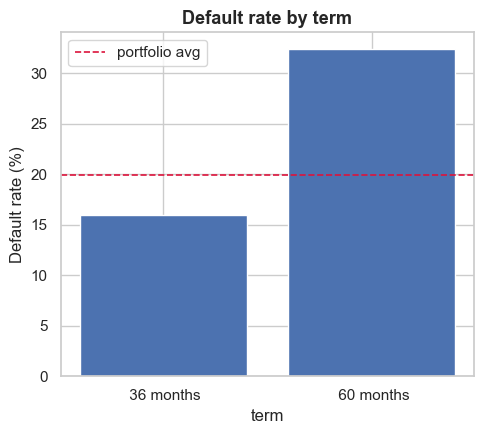

In [23]:
_ = default_rate_by("term", order=[" 36 months", " 60 months"], figsize=(5,4.5))

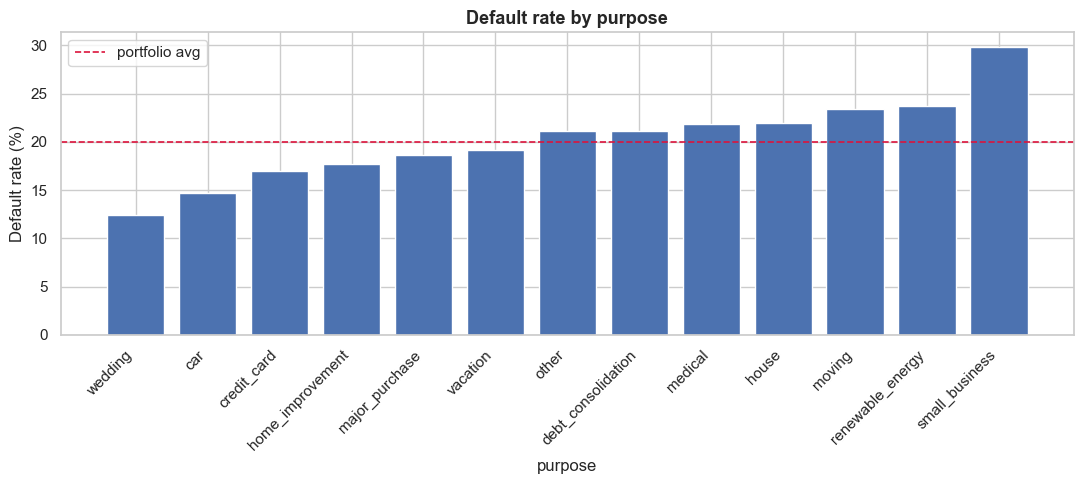

In [24]:
if "purpose" in term.columns:
    _ = default_rate_by("purpose", rotate=45, figsize=(11,5))

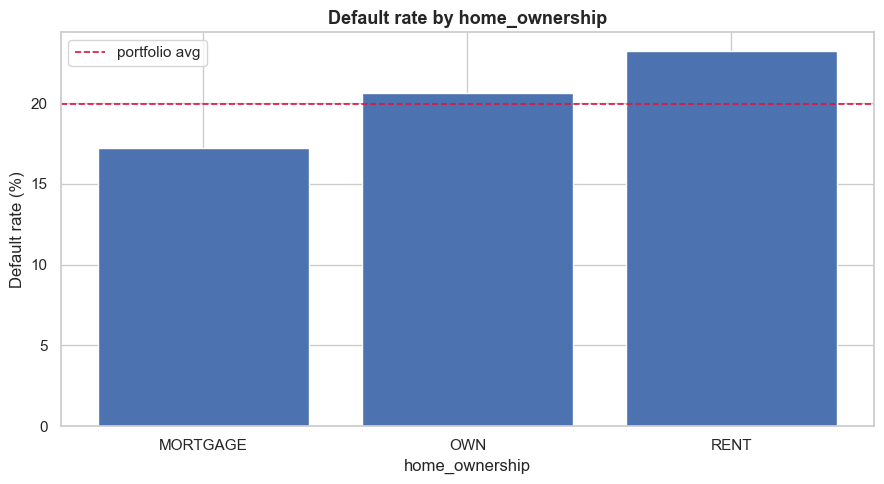

In [25]:
if "home_ownership" in term.columns:
    _ = default_rate_by("home_ownership", rotate=0)

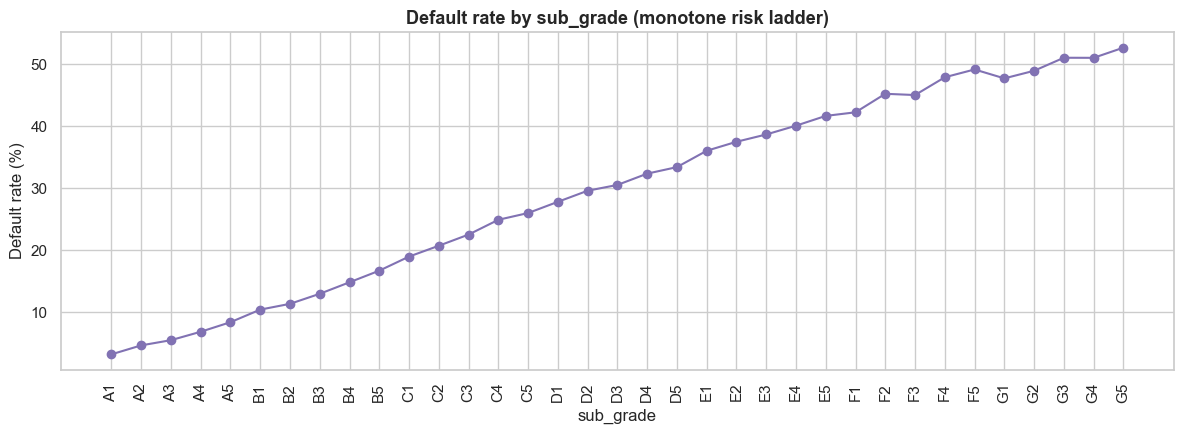

In [26]:
# sub_grade gives a finer, monotone risk ladder — strong signal but a judgment-call feature.
if "sub_grade" in term.columns:
    sg = (term.groupby("sub_grade")["target"].mean().mul(100)
            .sort_index())
    fig, ax = plt.subplots(figsize=(12,4.5))
    ax.plot(sg.index, sg.values, marker="o", color="#8172B3")
    ax.set_title("Default rate by sub_grade (monotone risk ladder)")
    ax.set_xlabel("sub_grade"); ax.set_ylabel("Default rate (%)")
    plt.setp(ax.get_xticklabels(), rotation=90)
    plt.tight_layout(); plt.show()

### 5.1 · FICO and interest rate by outcome

Two continuous separators: defaulters tend to have lower application FICO and
(because LendingClub priced the risk) higher interest rates.

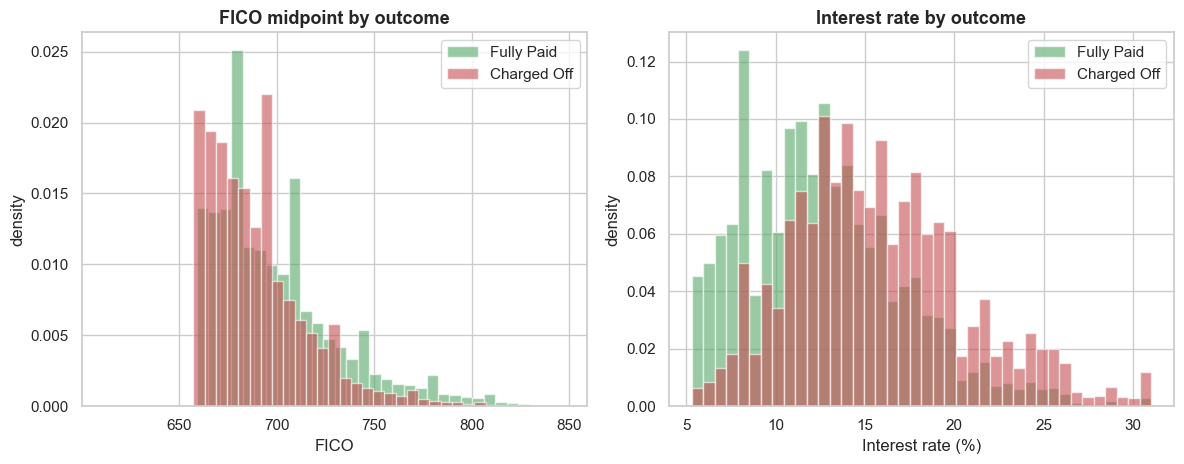

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for t, c, lab in [(0, "#55A868", "Fully Paid"), (1, "#C44E52", "Charged Off")]:
    axes[0].hist(term.loc[term.target==t, "fico_mid"].dropna(),
                 bins=40, alpha=0.6, color=c, label=lab, density=True)
axes[0].set_title("FICO midpoint by outcome")
axes[0].set_xlabel("FICO"); axes[0].set_ylabel("density"); axes[0].legend()

for t, c, lab in [(0, "#55A868", "Fully Paid"), (1, "#C44E52", "Charged Off")]:
    axes[1].hist(term.loc[term.target==t, "int_rate_num"].dropna(),
                 bins=40, alpha=0.6, color=c, label=lab, density=True)
axes[1].set_title("Interest rate by outcome")
axes[1].set_xlabel("Interest rate (%)"); axes[1].set_ylabel("density"); axes[1].legend()

plt.tight_layout(); plt.show()

## 6 · Charge-off rate over time (vintage analysis)

Credit conditions shifted across 2007–2018. Plotting the default rate by issue
month exposes the temporal drift that justifies a **time-based validation split**
in addition to stratified k-fold. Read the tail cautiously — recent vintages are
censored (Section 2.1).

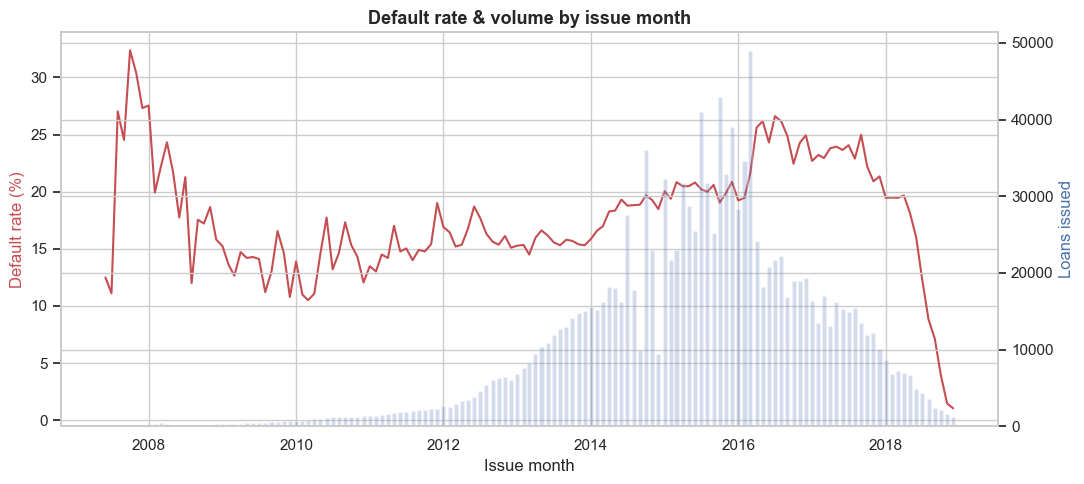

In [28]:
term["issue_dt"] = pd.to_datetime(term["issue_d"], format="%b-%Y", errors="coerce")
by_month = (term.dropna(subset=["issue_dt"])
                .groupby(term["issue_dt"].dt.to_period("M"))["target"]
                .agg(["mean", "size"]))
by_month.index = by_month.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(by_month.index, by_month["mean"]*100, color="#C44E52", label="default rate")
ax1.set_ylabel("Default rate (%)", color="#C44E52")
ax1.set_xlabel("Issue month"); ax1.set_title("Default rate & volume by issue month")

ax2 = ax1.twinx()
ax2.bar(by_month.index, by_month["size"], width=20, alpha=0.25,
        color="#4C72B0", label="loans issued")
ax2.set_ylabel("Loans issued", color="#4C72B0")
fig.tight_layout(); plt.show()

## 7 · Numeric correlation heatmap

A correlation matrix over the whitelisted numeric features flags multicollinearity
(e.g. FICO fields, installment vs. loan amount) to address in preprocessing.

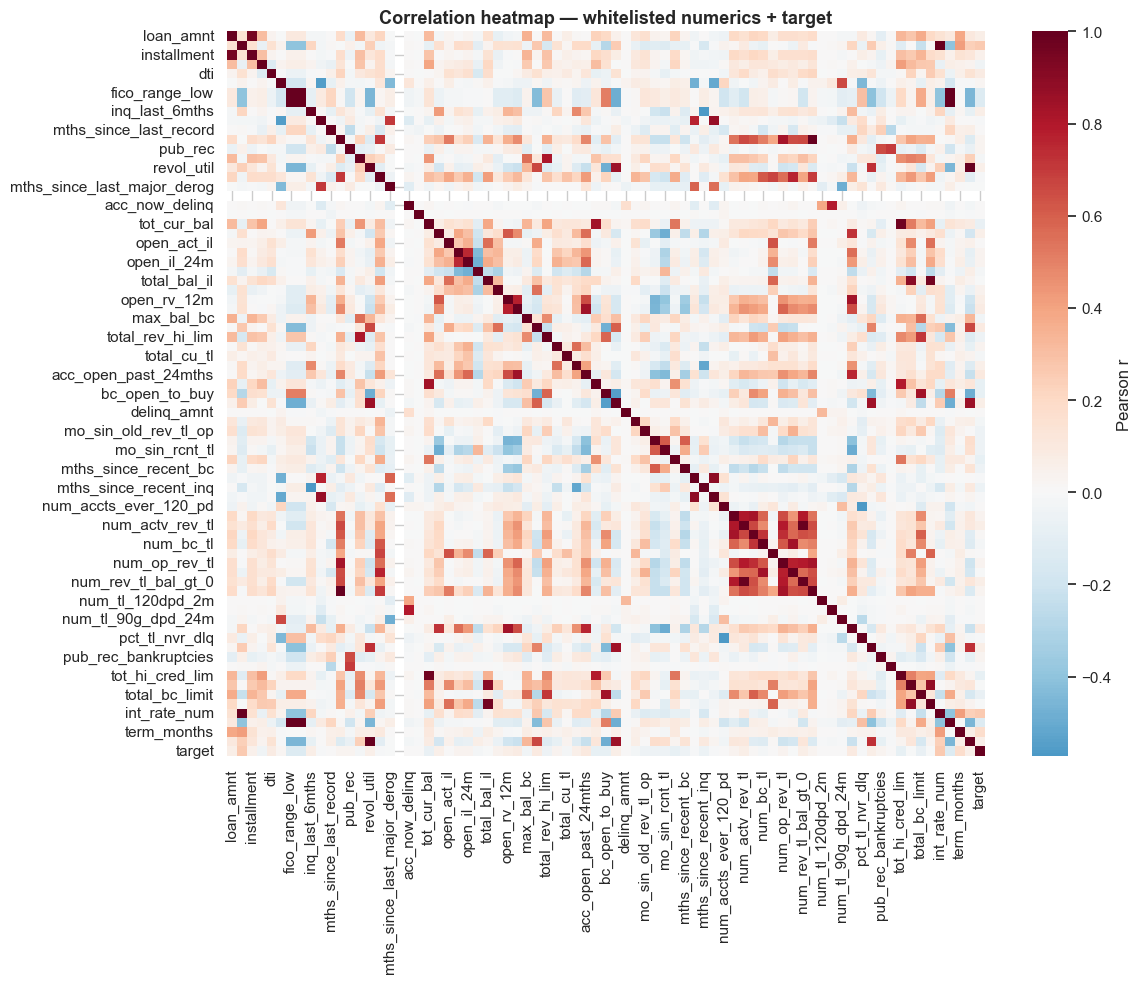

Top absolute correlations with target:
int_rate_num            0.258577
int_rate                0.258577
term_months             0.175749
fico_range_low          0.130701
fico_mid                0.130700
fico_range_high         0.130700
acc_open_past_24mths    0.099873
all_util                0.088977
num_tl_op_past_12m      0.085622
dti                     0.084215
bc_open_to_buy          0.082037
open_rv_24m             0.081914
Name: target, dtype: float64


In [29]:
num_whitelist = [c for c in whitelist
                 if c in term.columns and pd.api.types.is_numeric_dtype(term[c])]
# add the parsed/engineered numerics
for c in ["int_rate_num", "fico_mid", "term_months", "revol_util_num"]:
    if c in term.columns and c not in num_whitelist:
        num_whitelist.append(c)

corr = term[num_whitelist + ["target"]].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=False,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation heatmap — whitelisted numerics + target")
plt.tight_layout(); plt.show()

# Features most correlated with the target (linear signal only).
print("Top absolute correlations with target:")
print(corr["target"].drop("target").abs().sort_values(ascending=False).head(12))

## 8 · Save the interim modeling sample

We persist a compact, target-labelled, whitelist-only frame to `data/interim/`
as Parquet so the preprocessing and modeling notebooks load in seconds instead of
minutes. (Parquet preserves dtypes and is far smaller than CSV.)

In [30]:
keep_cols = [c for c in whitelist if c in term.columns]
extra = ["target", "issue_dt", "term_months", "int_rate_num",
         "revol_util_num", "fico_mid"]
keep_cols = keep_cols + [c for c in extra if c in term.columns and c not in keep_cols]

model_df = term[keep_cols].copy()
out_path = os.path.join(INTERIM_DIR, "accepted_terminal_whitelist.parquet")
try:
    model_df.to_parquet(out_path, index=False)
    print(f"Saved {model_df.shape} -> {out_path}")
except Exception as e:
    out_path = out_path.replace(".parquet", ".csv")
    model_df.to_csv(out_path, index=False)
    print(f"Parquet unavailable ({e}); saved CSV -> {out_path}")

Saved (1348099, 91) -> C:\Users\Orion\Downloads\data\interim\accepted_terminal_whitelist.parquet


## 9 · Rejected applications — load, sample, profile

The rejected file is 27.6M rows × 9 columns (~10.5 GB). We read only what we need,
in chunks, keeping a **random sample** for the access/policy analysis and computing
full-file missingness for `Risk_Score` along the way.

In [31]:
REJECTED_USECOLS = [
    "Amount Requested", "Application Date", "Loan Title", "Risk_Score",
    "Debt-To-Income Ratio", "Zip Code", "State", "Employment Length", "Policy Code",
]

chunks, total_rows, risk_missing = [], 0, 0
rng = np.random.default_rng(RANDOM_STATE)
keep_prob = None  # set after first estimate; use fixed prob for simplicity

# Fixed keep-probability sampling to land near REJECTED_SAMPLE_N without two passes.
# 27.6M rows -> ~0.018 keeps ~500k.
keep_prob = min(1.0, REJECTED_SAMPLE_N / 27_648_741)

for chunk in pd.read_csv(REJECTED_CSV, usecols=REJECTED_USECOLS,
                         chunksize=1_000_000, low_memory=False):
    total_rows += len(chunk)
    risk_missing += chunk["Risk_Score"].isna().sum()
    mask = rng.random(len(chunk)) < keep_prob
    chunks.append(chunk.loc[mask])

rej = pd.concat(chunks, ignore_index=True)
print(f"Rejected file total rows: {total_rows:,}")
print(f"Risk_Score missing: {risk_missing/total_rows*100:.1f}% (pitch expected ~66.9%)")
print(f"Sampled rejected rows kept: {len(rej):,}")

Rejected file total rows: 27,648,741
Risk_Score missing: 66.9% (pitch expected ~66.9%)
Sampled rejected rows kept: 499,594


In [32]:
# Parse rejected fields to comparable numerics.
rej["amount_requested"] = pd.to_numeric(rej["Amount Requested"], errors="coerce")
rej["dti_num"]          = pct_str_to_float(rej["Debt-To-Income Ratio"])
rej["risk_score"]       = pd.to_numeric(rej["Risk_Score"], errors="coerce")
rej["app_dt"]           = pd.to_datetime(rej["Application Date"], errors="coerce")
rej["app_year"]         = rej["app_dt"].dt.year

missingness(rej)

,n_missing,pct_missing,dtype,n_unique
Risk_Score,333992,66.85,float64,593
risk_score,333992,66.85,float64,593
Employment Length,17176,3.44,object,11
Loan Title,32,0.01,object,1985
Amount Requested,0,0.00,float64,1680
Application Date,0,0.00,object,3905
Debt-To-Income Ratio,0,0.00,object,20218
Zip Code,2,0.00,object,951
State,0,0.00,object,51
Policy Code,22,0.00,float64,2


## 10 · Accepted vs. rejected — the access/policy funnel

We harmonize the shared fields and compare approved vs. declined applicants. This
is **not** a claim about whether declined applicants *would* have defaulted (no
outcome exists for them) — it characterizes the client's historical **approval
behavior** for the fairness/policy lens.

In [33]:
# Harmonized accepted-side frame on shared fields.
acc_shared = pd.DataFrame({
    "amount":     term["loan_amnt"].astype(float),
    "credit":     term["fico_mid"],                 # FICO midpoint
    "dti":        term["dti"].astype(float),
    "year":       term["issue_dt"].dt.year,
    "state":      term.get("addr_state"),
    "approved":   1,
})
rej_shared = pd.DataFrame({
    "amount":     rej["amount_requested"],
    "credit":     rej["risk_score"],                # different scale — compare cautiously
    "dti":        rej["dti_num"],
    "year":       rej["app_year"],
    "state":      rej["State"],
    "approved":   0,
})
funnel = pd.concat([acc_shared, rej_shared], ignore_index=True)
print("Approved vs declined (sampled):")
print(funnel["approved"].value_counts())
print("\n?? Credit scores are on DIFFERENT scales (FICO vs LC Risk_Score) — "
      "the credit panel below is directional only.")

Approved vs declined (sampled):
approved
1    1348099
0     499594
Name: count, dtype: int64

?? Credit scores are on DIFFERENT scales (FICO vs LC Risk_Score) — the credit panel below is directional only.


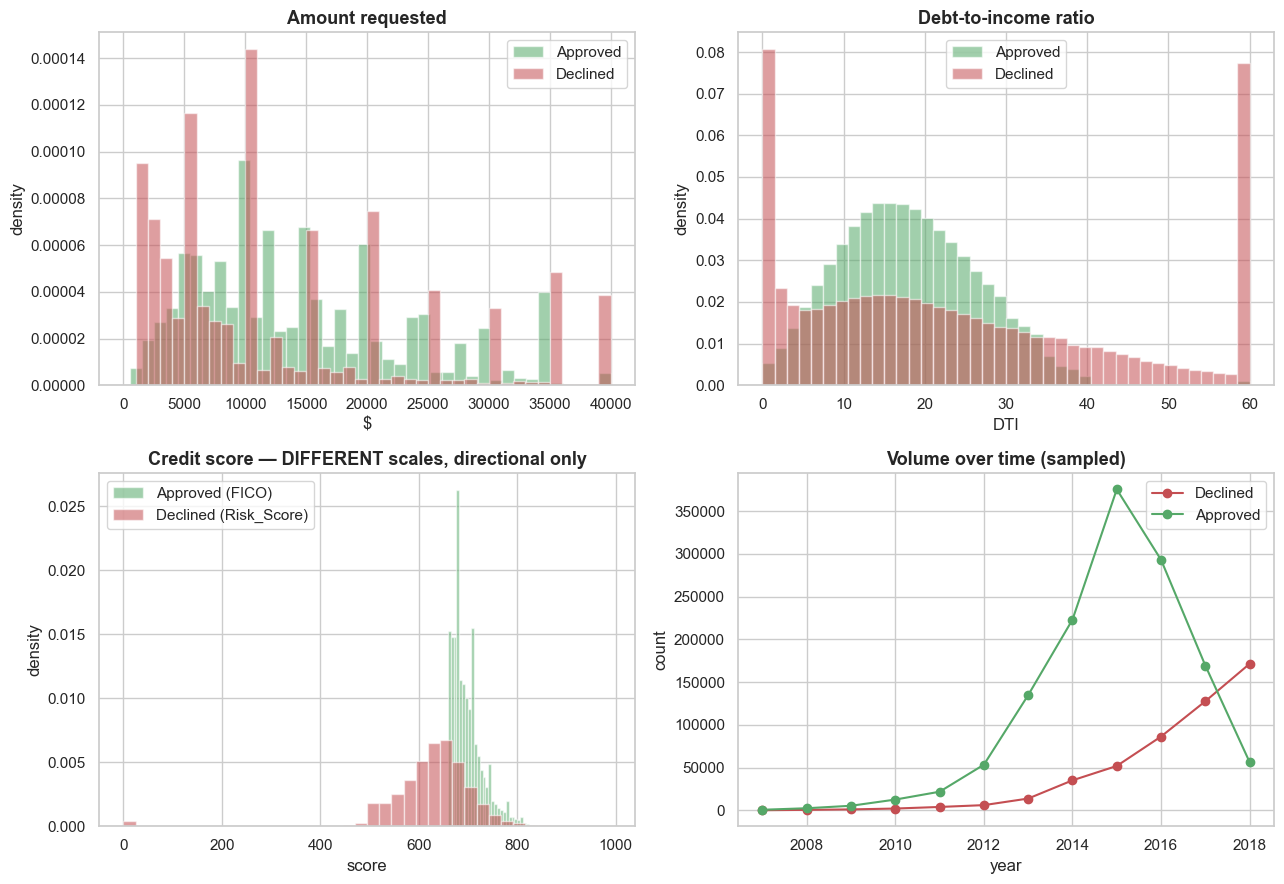

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Amount requested
for a, c, lab in [(1,"#55A868","Approved"), (0,"#C44E52","Declined")]:
    d = funnel.loc[funnel.approved==a, "amount"].dropna().clip(upper=40000)
    axes[0,0].hist(d, bins=40, alpha=0.55, density=True, color=c, label=lab)
axes[0,0].set_title("Amount requested"); axes[0,0].set_xlabel("$")
axes[0,0].set_ylabel("density"); axes[0,0].legend()

# DTI
for a, c, lab in [(1,"#55A868","Approved"), (0,"#C44E52","Declined")]:
    d = funnel.loc[funnel.approved==a, "dti"].dropna().clip(lower=0, upper=60)
    axes[0,1].hist(d, bins=40, alpha=0.55, density=True, color=c, label=lab)
axes[0,1].set_title("Debt-to-income ratio"); axes[0,1].set_xlabel("DTI")
axes[0,1].set_ylabel("density"); axes[0,1].legend()

# Credit score (directional)
for a, c, lab in [(1,"#55A868","Approved (FICO)"), (0,"#C44E52","Declined (Risk_Score)")]:
    d = funnel.loc[funnel.approved==a, "credit"].dropna()
    axes[1,0].hist(d, bins=40, alpha=0.55, density=True, color=c, label=lab)
axes[1,0].set_title("Credit score — DIFFERENT scales, directional only")
axes[1,0].set_xlabel("score"); axes[1,0].set_ylabel("density"); axes[1,0].legend()

# Applications over time
counts = (funnel.dropna(subset=["year"])
                .groupby(["year","approved"]).size().unstack(fill_value=0))
counts.plot(ax=axes[1,1], marker="o",
            color={0:"#C44E52",1:"#55A868"})
axes[1,1].set_title("Volume over time (sampled)")
axes[1,1].set_xlabel("year"); axes[1,1].set_ylabel("count")
axes[1,1].legend(["Declined","Approved"])

plt.tight_layout(); plt.show()

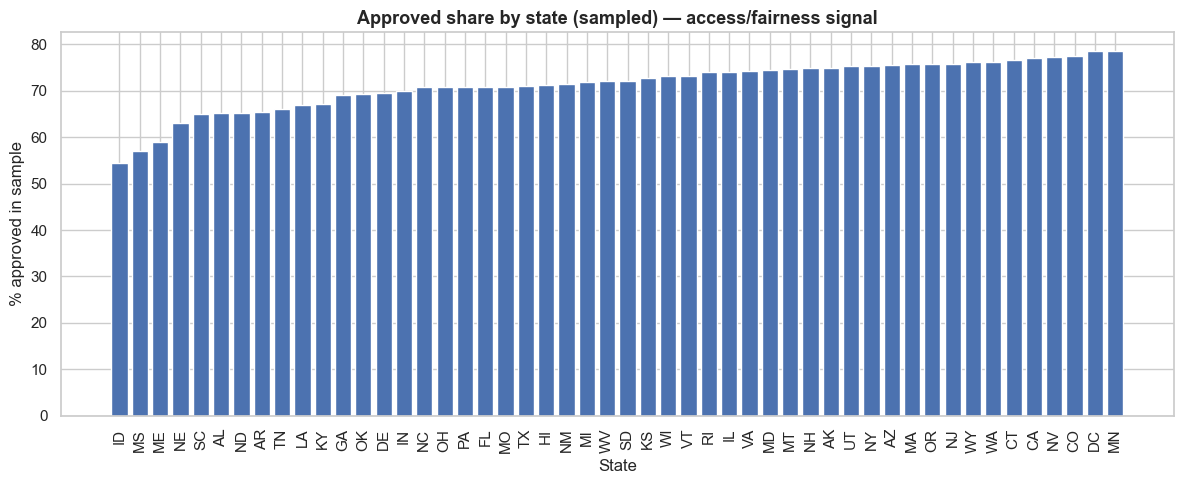

In [35]:
# Approval geography — declined share by state (sampled, directional).
state_appr = (funnel.dropna(subset=["state"])
                    .groupby("state")["approved"].agg(["mean","size"]))
state_appr = state_appr[state_appr["size"] >= 200].sort_values("mean")
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(state_appr.index, state_appr["mean"]*100, color="#4C72B0")
ax.set_title("Approved share by state (sampled) — access/fairness signal")
ax.set_xlabel("State"); ax.set_ylabel("% approved in sample")
plt.setp(ax.get_xticklabels(), rotation=90); plt.tight_layout(); plt.show()

## 11 · EDA summary → decisions carried forward

**Data quality**
- Dropped the all-null "junk" rows; parsed string numerics (`term`, `int_rate`,
  `revol_util`, rejected `Debt-To-Income Ratio`).
- Near-empty blocks (`member_id`, `hardship_*`, `settlement_*`, `sec_app_*`,
  `desc`) confirmed for dropping; `Risk_Score` ~67% missing in the rejected file.

**Target**
- Binary default target built on terminal loans only; ~20% default rate confirmed.
- **Vintage survivorship** documented (Section 2.1) — flag when reading the
  time-based split.

**Leakage**
- Full column audit saved to `data/interim/column_audit.csv`; a **whitelist** of
  application-time features drives modeling. `grade`/`sub_grade`/`int_rate` held
  out as judgment-call features to test **with and without**.

**Signal**
- Strong, sensible drivers: grade/sub_grade ladder, term, purpose, FICO, DTI,
  interest rate; temporal drift visible across vintages.

**Access/policy**
- Harmonized accepted-vs-rejected comparison built; credit-score scales differ
  (compare directionally); geographic approval variation flagged for the fairness
  lens. `Policy Code` excluded as an approval-label proxy.

**Next notebook (02_Preprocessing):** build the `ColumnTransformer` + `Pipeline`
on the whitelist, engineer the `mths_since_*` "never" flags and credit-history
length, handle imbalance inside CV folds, and set up stratified + time-based splits.